<a href="https://colab.research.google.com/github/niuers/makemore/blob/master/makemore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/niuers/makemore.git

Cloning into 'makemore'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 110 (delta 45), reused 18 (delta 16), pack-reused 23 (from 1)
Receiving objects: 100% (110/110), 752.36 KiB | 6.84 MiB/s, done.
Resolving deltas: 100% (61/61), done.


In [2]:
!git config --global user.email "nzquantfin@google.com"
!git config --global user.name "NZ"

First, retrieve your PAT from Colab's Secrets Manager:

In [3]:
from google.colab import userdata

# Replace 'GITHUB_PAT' with the name you gave your secret
GITHUB_PAT = userdata.get('GITHUB_PAT')

Now, configure Git to use the PAT for authentication. Replace `github.com` with your Git provider's domain if you are not using GitHub.

In [4]:
import os

# Get the current directory to handle potential changes
current_dir = os.getcwd()

# Change to the cloned repository directory if necessary
# Replace 'handson-mlp' with the name of your repository folder
repo_dir = os.path.join(current_dir, 'makemore')

# Check if the directory exists before changing to it
if os.path.exists(repo_dir):
    os.chdir(repo_dir)
    print(f"Changed directory to: {os.getcwd()}")
else:
    print(f"Repository directory not found: {repo_dir}. Please ensure you have cloned the repository.")
    # You might want to add logic here to handle the case where the repo is not cloned

# Configure git to use the PAT
# This command will replace the password with the PAT when pushing
!git config --global url."https://{GITHUB_PAT}@github.com".insteadOf "https://github.com"

# Change back to the original directory if you changed it
os.chdir(current_dir)
print(f"Changed back to original directory: {os.getcwd()}")

print("\nGit is now configured to use your PAT.")

Changed directory to: /content/makemore
Changed back to original directory: /content

Git is now configured to use your PAT.


In [5]:
# !git config --global credential.helper 'cache --timeout 3600'
!alias gs="git status"
!alias gc="git commit -m"
!alias gp="git push"

In [7]:
%%shell
echo 'alias gs="git status"' >> ~/.bashrc
echo 'alias gc="git commit -m"' >> ~/.bashrc
echo 'alias gp="git push"' >> ~/.bashrc
source ~/.bashrc

# Note: While these aliases are added to .bashrc, their availability
# for subsequent '!' or '%%shell' commands in other cells
# may vary in the Colab environment.
# You might need to define them directly within each %%shell block
# where you want to use them for consistent behavior.

In [8]:
!pwd

/content


In [9]:
import sys
import os

# Get the current directory
current_dir = os.getcwd()

# # Add the handson-mlp directory to sys.path
# # Assuming handson-mlp is cloned in the /content directory
mm_path = os.path.join(current_dir, 'makemore')
sys.path.append(mm_path)

# from src.dummy import my_dummy
# my_dummy(1)

# some random words

In [10]:
import os

# Get the current working directory
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

# Change the current working directory to /content/makemore
os.chdir('/content/makemore')
print(f"Changed to directory: {os.getcwd()}")

# You can now access files in /content/makemore directly by their names

# To change back to the original directory
# os.chdir(current_dir)
# print(f"Changed back to original directory: {os.getcwd()}")

Current directory: /content
Changed to directory: /content/makemore


In [11]:
words = open('names.txt', 'r').read().splitlines()
len(words)
min(len(w) for w in words), max(len(w) for w in words)

(2, 15)

# Bi-Gram Language Model

In [ ]:
from collections import defaultdict
b = defaultdict(int)
for w in words:
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    b[(ch1, ch2)] += 1
print(len(b), b[('e','m')])

627 769


In [ ]:
# sorted(b.items(), key=lambda kv: -kv[1])

In [ ]:
import torch


In [ ]:
N = torch.zeros((28,28), dtype=torch.int32)
# # a.dtype
# a[0]

In [ ]:
import torch

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
# stoi['<S>'] = 26
# stoi['<E>'] = 27

N = torch.zeros((27,27), dtype=torch.int32)

for w in words:
  # chs = ['<S>'] + list(w) + ['<E>']
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    N[stoi[ch1], stoi[ch2]] += 1
itos = {i:s for s, i in stoi.items()}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

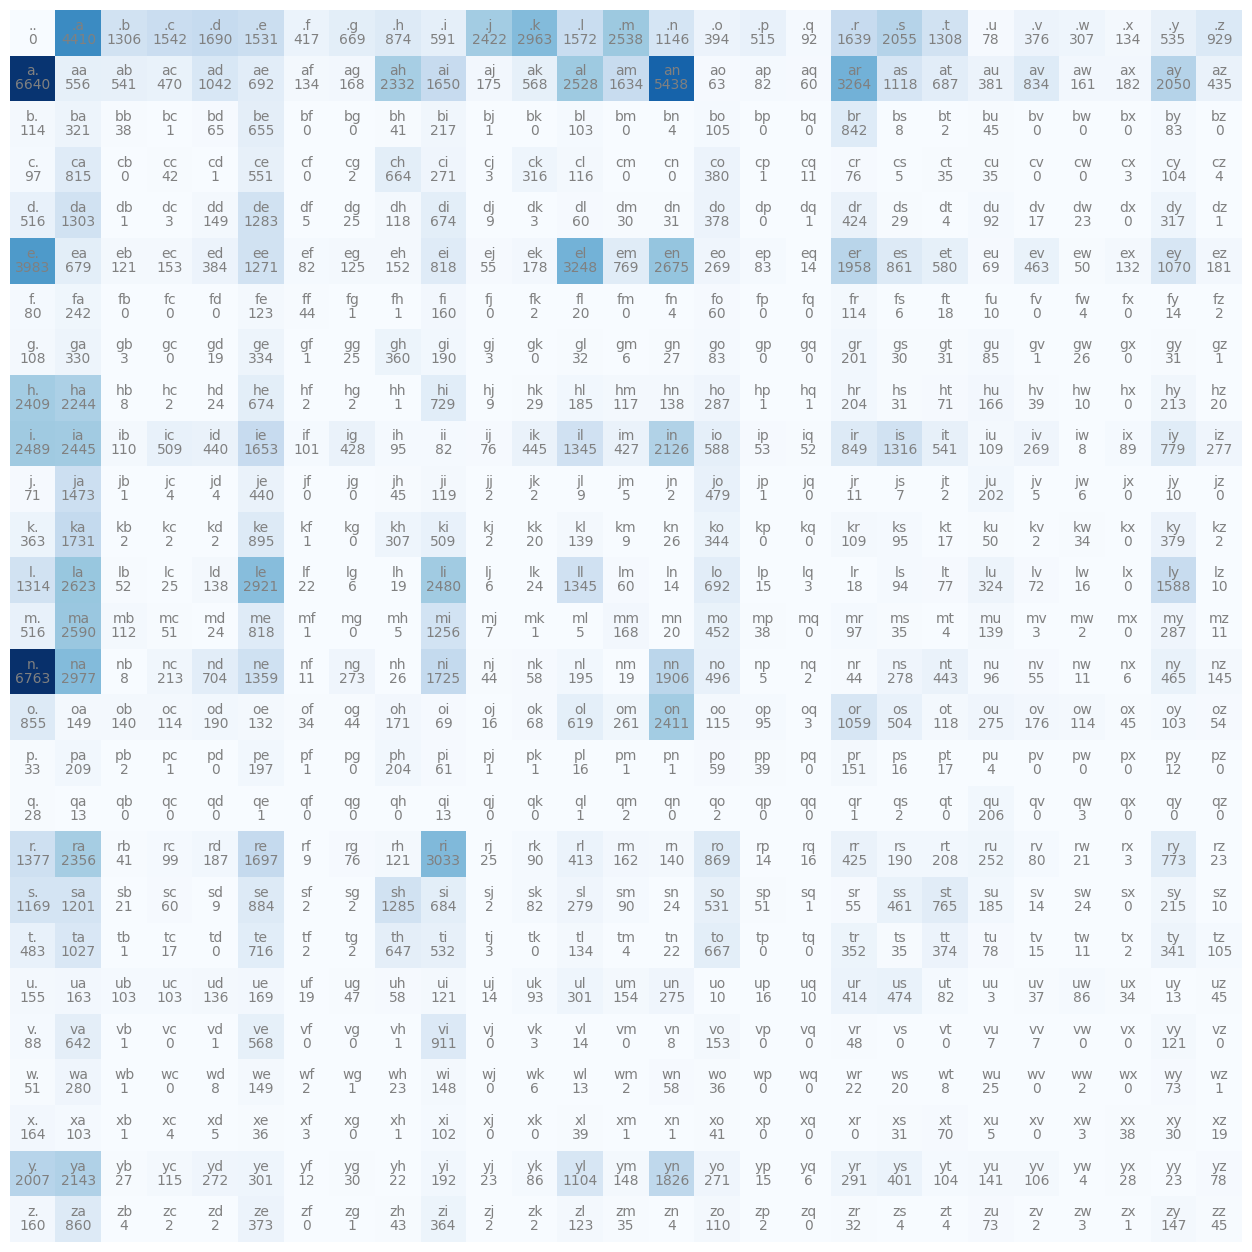

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j,i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j,i,N[i,j].item(), ha="center", va="top", color='gray')
plt.axis('off')


In [ ]:
# N[0].shape


g = torch.Generator().manual_seed(2147483647)
p= torch.rand(3, generator=g)
print(p)
p = p/p.sum()
p

tensor([0.7081, 0.3542, 0.1054])


tensor([0.6064, 0.3033, 0.0903])

In [ ]:
p = N[0].float()
p /= p.sum()
print(p)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])


'y'

In [ ]:
P = N.float()
ps = P.sum(1)
print(ps.shape)
r= P/ps
print(ps)
print(P[0])
print(r[0], r[:, 0].sum())


torch.Size([27])
tensor([32033., 33885.,  2645.,  3532.,  5496., 20423.,   905.,  1927.,  7616.,
        17701.,  2900.,  5040., 13958.,  6642., 18327.,  7934.,  1026.,   272.,
        12700.,  8106.,  5570.,  3135.,  2573.,   929.,   697.,  9776.,  2398.])
tensor([   0., 4410., 1306., 1542., 1690., 1531.,  417.,  669.,  874.,  591.,
        2422., 2963., 1572., 2538., 1146.,  394.,  515.,   92., 1639., 2055.,
        1308.,   78.,  376.,  307.,  134.,  535.,  929.])
tensor([0.0000, 0.1301, 0.4938, 0.4366, 0.3075, 0.0750, 0.4608, 0.3472, 0.1148,
        0.0334, 0.8352, 0.5879, 0.1126, 0.3821, 0.0625, 0.0497, 0.5019, 0.3382,
        0.1291, 0.2535, 0.2348, 0.0249, 0.1461, 0.3305, 0.1923, 0.0547, 0.3874]) tensor(1.)


In [ ]:
4410/33885, 1306/2645

(0.1301460823373174, 0.4937618147448015)

In [ ]:
P = N.float()
print(P.shape)
ps = P.sum(1, keepdim=True)
print(ps.shape)
# print(ps)
P = P/ps
print(P.shape, P[0].sum())

torch.Size([27, 27])
torch.Size([27, 1])
torch.Size([27, 27]) tensor(1.)


In [ ]:

g = torch.Generator().manual_seed(2147483647)
P = (N+1).float()
P /= P.sum(1, keepdim=True)
for i in range(20):
  out = []
  ix = 0
  while True:
    # p = N[ix].float()
    # p /= p.sum()
    # p = torch.ones(27)/27.0
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [ ]:
log_likelihood = 0
n = 0
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    # print(f"{ch1}{ch2}: {prob:.4f}, {logprob:.4f}")
print(f"{log_likelihood=}")
nll = -log_likelihood
print(f"{nll/n=}")

log_likelihood=tensor(-559951.5625)
nll/n=tensor(2.4544)


# Neural Network

In [ ]:
# create the training set of bigrams (x,y)
xs, ys = [], []

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [ ]:
xs.shape, ys.shape

(torch.Size([228146]), torch.Size([228146]))

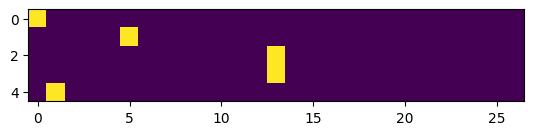

In [ ]:
xenc = F.one_hot(xs[:5], num_classes=27)
plt.imshow(xenc)

In [ ]:
# xenc.dtype
import torch.nn.functional as F

# nlls = torch.zeros(5)
# for i in range(5):
#   x = xs[i].item()
#   y = ys[i].item()
#   p = probs[i, y]
#   logp = torch.log(p)
#   nll = -logp
#   nlls[i] = nll
# print(nlls.mean().item())



In [ ]:

import torch.nn.functional as F

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

iters = 100
for i in range(iters):
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # log-counts
  # softmax
  counts = logits.exp() # equivalent N
  probs = counts/ counts.sum(1, keepdim=True) # probabilities for the next characters
  # compute NLL
  n = xs.shape[0]
  loss = - probs[torch.arange(n), ys].log().mean() + 0.01 * (W**2).mean()
  print(loss.item())
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  # update
  W.data += -10* W.grad

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  out = []
  ix = 0
  while True:
    # before p = P[ix]
    # Now
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    p = counts/ counts.sum(1, keepdim=True)

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


cexze.
momasurailezityha.
konimittain.
llayn.
ka.


In [ ]:
torch.arange(5)
W.grad.shape

# MLP

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
words = open('names.txt', 'r').read().split()
len(words), words[:5]

(32033, ['emma', 'olivia', 'ava', 'isabella', 'sophia'])

In [ ]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
print(stoi)
itos = {i:s for s,i in stoi.items()}
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset
X, Y = [], []
block_size = 3 # context length: how many characters do we take to predict the next one?
for w in words:
  # print(w)
  context = [0]*block_size
  for ch in w+'.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '-->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, X.dtype, Y.shape, Y.dtype)


torch.Size([228146, 3]) torch.int64 torch.Size([228146]) torch.int64


In [ ]:
# build embedding
C = torch.randn((27, 2))
C[torch.tensor([5,6,7])]

tensor([[ 0.5083, -0.5252],
        [-0.7769,  0.8849],
        [ 1.0994, -1.5740]])

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.5083, -0.5252])

In [ ]:

C[X].shape

torch.Size([228146, 3, 2])

In [ ]:
print(X[13], X[13,2], C[X][13,2], C[1])

tensor([0, 0, 1]) tensor(1) tensor([0.2709, 0.6287]) tensor([0.2709, 0.6287])


In [ ]:


emb = C[X]
# Different ways to flat the embedding

# method 1
# print(emb.shape, emb[:, 0, :], emb[:, 1, :], emb[:, 2, :])
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

# method 2, inefficient
torch.cat(torch.unbind(emb, 1), 1).shape

# method 3: Use view

a = torch.arange(18)
a, a.view((9,2)), a.storage()
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

/tmp/ipython-input-505610096.py:14: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a, a.view((9,2)), a.storage()


RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [ ]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [ ]:
# Construct hidden layer
# build embedding
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g) # 6 = 3x2
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

3481


In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs.shape,

(torch.Size([1000]),)

In [ ]:
# Forward Pass

lri = []
lossi = []

for i in range(1000):

  #mini batch
  ix = torch.randint(0, X.shape[0], (32,))

  # concatonate embeddings
  emb = C[X[ix]] # (32, 3, 2)
  # embcat = emb.view(-1, 6)
  h = torch.tanh(emb.view(-1, 6) @W1 + b1) # (32, 100)
  # print(h.shape)
  logits = h @ W2 + b2 # (32, 27)
  # print(logits.shape)
  loss = F.cross_entropy(logits, Y[ix])

  # counts = logits.exp()
  # probs = counts/ counts.sum(1, keepdim=True)
  # print(probs.shape)
  # loss = -probs[torch.arange(32), Y].log().mean()
  # print(loss.item())

  # Backward Pass
  # set grade zero
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  lri.append(lre[i])
  lossi.append(loss.item())
print(loss.item())

7.080867290496826


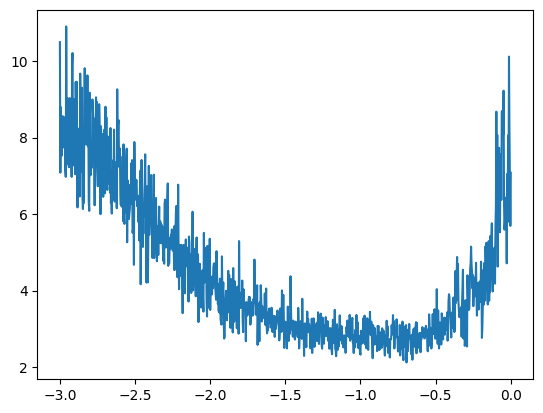

In [ ]:
plt.plot(lri, lossi)

In [ ]:
emb = C[X] # (32, 3, 2)
# embcat = emb.view(-1, 6)
h = torch.tanh(emb.view(-1, 6) @W1 + b1) # (32, 100)
# print(h.shape)
logits = h @ W2 + b2 # (32, 27)
# print(logits.shape)
loss = F.cross_entropy(logits, Y)
loss.item()

2.612945795059204

In [ ]:

# # update
# logits = torch.tensor([-5, -3, 0, 50]) -50
# counts = logits.exp()
# probs = counts / counts.sum()
# probs
print(logits.max(1))
print(Y)

torch.return_types.max(
values=tensor([ 8.2985,  9.8879, 18.4876,  ..., 11.3038, 13.8946, 12.4195],
       grad_fn=<MaxBackward0>),
indices=tensor([ 9,  8,  9,  ..., 15, 11, 17]))
tensor([ 5, 13, 13,  ..., 26, 24,  0])


In [ ]:
torch.randint(0, X.shape[0], (32,))

tensor([129994,  15011, 149744, 210601, 161312, 176459, 222170, 181987,  47961,
        100896,  99197,  37906, 225546, 123940,  30393, 126646,  99837,   6711,
          7076, 124441, 174845, 141942, 199066,  33933,  83475,   8861, 215476,
        162799, 154404,  47183,  40793,  33349])

In [ ]:
# training split, dev/valiation split, test split
# 80%, 10%, 10%

# Makemore: Part 3

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
words = open('names.txt', 'r').read().split()
print(len(words), words[:5])
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
print(stoi)
itos = {i:s for s,i in stoi.items()}
print(itos)
vocab_size = len(itos)
print(f"{vocab_size=}")

# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w+'.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), '-->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, X.dtype, Y.shape, Y.dtype)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

32033 ['emma', 'olivia', 'ava', 'isabella', 'sophia']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab_size=27
torch.Size([182625, 3]) torch.int64 torch.Size([182625]) torch.int64
torch.Size([22655, 3]) torch.int64 torch.Size([22655]) torch.int64
torch.Size([22866, 3]) torch.int64 torch.Size([22866]) torch.int64


In [23]:
# Construct hidden layer
# build embedding
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hiddenlayer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g) * (5/3)/(n_embd*block_size)**0.5 #* 0.2 # reduce activation saturation, make hpreact small
b1 = torch.randn(n_hidden, generator=g)  * 0.01 # to avoid dead neuron, also allow some variation and diversity in initialization
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # scale down, reduce logits to close to 0
b2 = torch.randn(vocab_size, generator=g) * 0 #want to initialize with 0, so the logits can be all close to 0

# batch normalization
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

12297


In [16]:
#Kaiming He Initialization
(torch.randn(1000)*0.2).std()
fan_in = n_embd*block_size
(5/3)/fan_in**0.5

0.3042903097250923

In [24]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  #mini batch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # Batch X, Y
  # concatonate embeddings
  emb = C[Xb] # (32, 3, 2)
  embcat = emb.view(emb.shape[0], -1)
  # embcat = emb.view(-1, 6)
  hpreact = embcat @W1+b1

  # Batch Normalization hpreact
  # running averages
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999*bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001*bnstdi

  h = torch.tanh(hpreact) # (32, 100)
  # print(h.shape)
  logits = h @ W2 + b2 # (32, 27)
  # print(logits.shape)
  loss = F.cross_entropy(logits, Yb)

  # counts = logits.exp()
  # probs = counts/ counts.sum(1, keepdim=True)
  # print(probs.shape)
  # loss = -probs[torch.arange(32), Y].log().mean()
  # print(loss.item())

  # Backward Pass
  # set grade zero
  for p in parameters:
    p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
  lossi.append(loss.log10().item())
  # break
print(loss.item())

      0/ 200000: 3.2874
  10000/ 200000: 2.2506
  20000/ 200000: 2.5127
  30000/ 200000: 2.0485
  40000/ 200000: 2.7647
  50000/ 200000: 2.3334
  60000/ 200000: 2.8682
  70000/ 200000: 2.4023
  80000/ 200000: 2.1564
  90000/ 200000: 2.3810
 100000/ 200000: 2.2388
 110000/ 200000: 1.9311
 120000/ 200000: 1.8478
 130000/ 200000: 2.0537
 140000/ 200000: 2.2018
 150000/ 200000: 2.0225
 160000/ 200000: 2.5882
 170000/ 200000: 2.3304
 180000/ 200000: 2.1381
 190000/ 200000: 1.9289
1.8954371213912964


In [19]:
hpreact.shape
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [ ]:
# Investigate the logits
logits[0] #want this to be all close to 0 to reduce entropy, so the algo starts with a resonably small loss

tensor([-0.1092, -0.0949,  0.0155, -0.0188,  0.0562,  0.0750, -0.0294,  0.0181,
        -0.1047,  0.0581,  0.0910,  0.0437,  0.0204, -0.0076, -0.0050,  0.0242,
         0.0328, -0.0336, -0.0149,  0.0677,  0.0515,  0.0571, -0.0410,  0.0670,
        -0.0110,  0.0308, -0.0704], grad_fn=<SelectBackward0>)

(array([175., 165., 185., 151., 157., 163., 142., 117., 123., 122., 112.,
         97., 112., 127., 100.,  96.,  97., 103., 106.,  91., 103.,  75.,
        101.,  96., 104., 110.,  97., 101.,  86.,  97.,  87., 121., 117.,
        117.,  98., 134., 119., 133., 115., 121., 134., 112., 128., 161.,
        153., 184., 175., 211., 252., 217.]),
 array([-9.99587297e-01, -9.59597524e-01, -9.19607751e-01, -8.79617978e-01,
        -8.39628205e-01, -7.99638432e-01, -7.59648659e-01, -7.19658886e-01,
        -6.79669113e-01, -6.39679340e-01, -5.99689567e-01, -5.59699794e-01,
        -5.19710021e-01, -4.79720248e-01, -4.39730475e-01, -3.99740702e-01,
        -3.59750929e-01, -3.19761156e-01, -2.79771383e-01, -2.39781610e-01,
        -1.99791837e-01, -1.59802064e-01, -1.19812291e-01, -7.98225176e-02,
        -3.98327446e-02,  1.57028437e-04,  4.01468015e-02,  8.01365745e-02,
         1.20126348e-01,  1.60116121e-01,  2.00105894e-01,  2.40095667e-01,
         2.80085440e-01,  3.20075213e-01,  3.60064

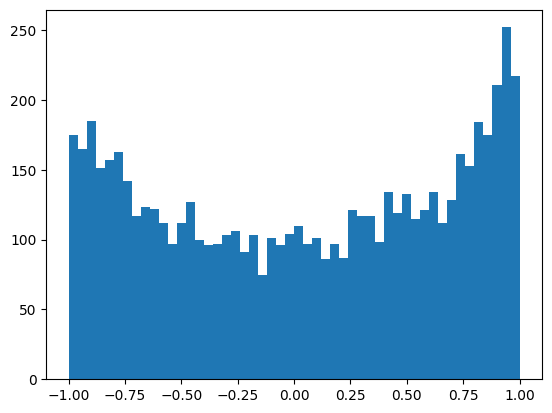

In [ ]:
# Investigate the values of h
# saturation of h: lots of 1 and -1
# t = tanh(x)
# dt/dx = (1-t^2) , this kills gradient when t is -1/1 and stops the backpropagation through this unit.
# You can see that the gradient through tanh can only decrease
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   1.,   0.,   1.,   3.,   8.,   6.,   9.,  16.,  13.,  29.,
         58.,  61.,  87., 135., 171., 207., 305., 284., 339., 406., 427.,
        421., 445., 473., 447., 393., 306., 303., 256., 202., 168., 115.,
        113.,  80.,  37.,  22.,  15.,  11.,  13.,   5.,   2.,   3.,   0.,
          1.,   0.,   0.,   0.,   0.,   2.]),
 array([-4.24288464, -4.0588533 , -3.87482197, -3.69079063, -3.5067593 ,
        -3.32272797, -3.13869663, -2.9546653 , -2.77063396, -2.58660263,
        -2.4025713 , -2.21853996, -2.03450863, -1.85047729, -1.66644596,
        -1.48241463, -1.29838329, -1.11435196, -0.93032063, -0.74628929,
        -0.56225796, -0.37822662, -0.19419529, -0.01016396,  0.17386738,
         0.35789871,  0.54193005,  0.72596138,  0.90999271,  1.09402405,
         1.27805538,  1.46208672,  1.64611805,  1.83014938,  2.01418072,
         2.19821205,  2.38224339,  2.56627472,  2.75030605,  2.93433739,
         3.11836872,  3.30240005,  3.48643139,  3.67046272,  3.85449406,
 

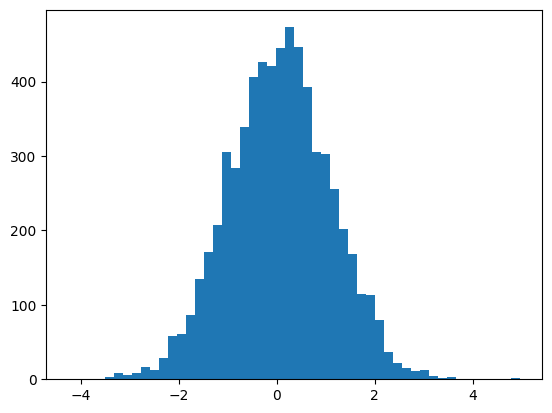

In [ ]:
plt.hist(hpreact.view(-1).tolist(), 50)

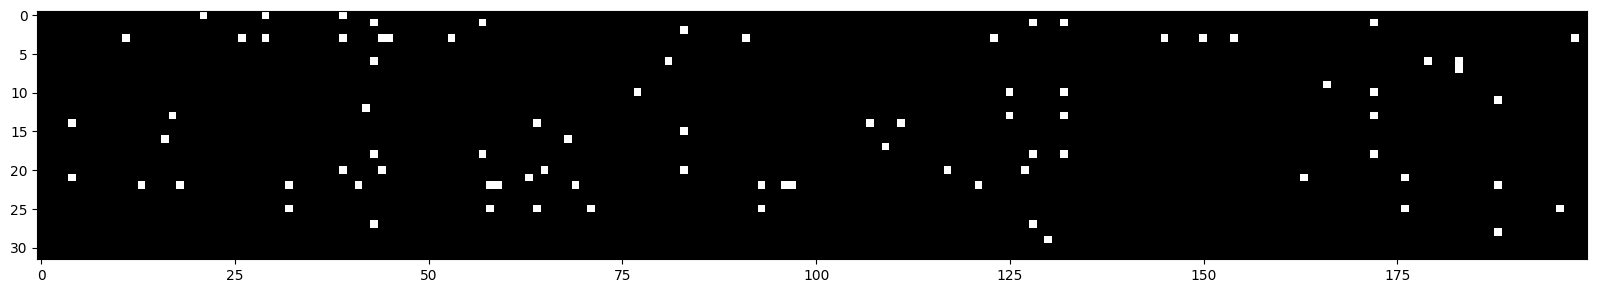

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')
# Dead neuron: if entire column is white

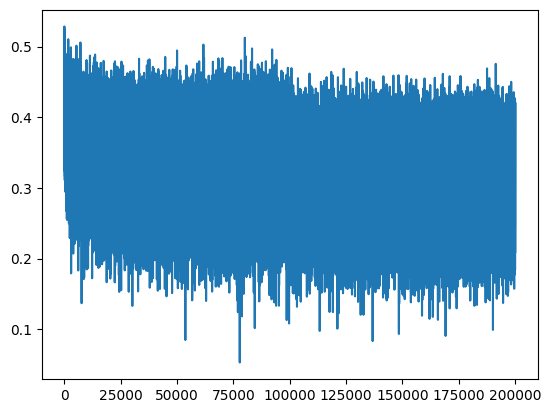

In [ ]:
plt.plot(lossi)

In [21]:
# calibrate the batch norm at the end of training
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [22]:
@torch.no_grad() # disables gradient tracking
def split_loss(split):
  x, y = {
      'train': (Xtr, Ytr),
      'val': (Xdev, Ydev),
      'test': (Xte, Yte)

  }[split]

  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size*n_embd)
  # Batch Normalization hpreact

  # N.B. The adding of b1 is wasteful here, as we normalize the hpreact, which subtracts b1 , so b1.grad is actually 0
  # So if you use batch normalization, you don't need bias at all. Instead, the bnbias is now in charge of biasing
  # of the distribution instead of this b1
  hpreact = embcat@W1+b1
  # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True) + bnbias
  # hpreact = bngain * (hpreact - bnmean)/bnstd + bnbias
  hpreact = bngain * (hpreact - bnmean_running)/bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.068107843399048
val 2.1099228858947754


In [ ]:
# loss log

# original:
train: 2.1245
val: 2.168

# fix softmax confidently wrong:
train 2.0690383911132812
val 2.13236927986145

# fix tanh layer too saturated at init
train 2.0354323387145996
val 2.102689266204834

# Add a batch normalization layer
train 2.0675084590911865
val 2.1058051586151123



In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647+10)
for _ in range(20):
  out = []
  context = [0]*block_size # initialize with all ...
  while True:
    emb = C[torch.tensor([context])] # (1, block_size, n_embd)
    h = torch.tanh(emb.view(1, -1)@W1+b1)
    logits = h@W2 + b2
    probs = F.softmax(logits, dim=1)

    # sample from the distribution
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    # shift the context window and track the samples
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

carmah.
ambril.
khy.
myli.
taty.
skanden.
jazhukwummerah.
pareei.
nellara.
chaiiv.
kaleigh.
ham.
pori.
quinn.
sulin.
alianni.
wazelo.
dearisi.
fran.
pirrat.


## Initialization

In [ ]:
-torch.tensor(1/27).log()

# 4-d example of the issue
logits = torch.tensor([5,5,5,5], dtype=torch.float32)
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
print(probs, loss)

tensor([0.2500, 0.2500, 0.2500, 0.2500]) tensor(1.3863)


tensor(0.0068) tensor(1.0095)
tensor(0.0017) tensor(0.9987)


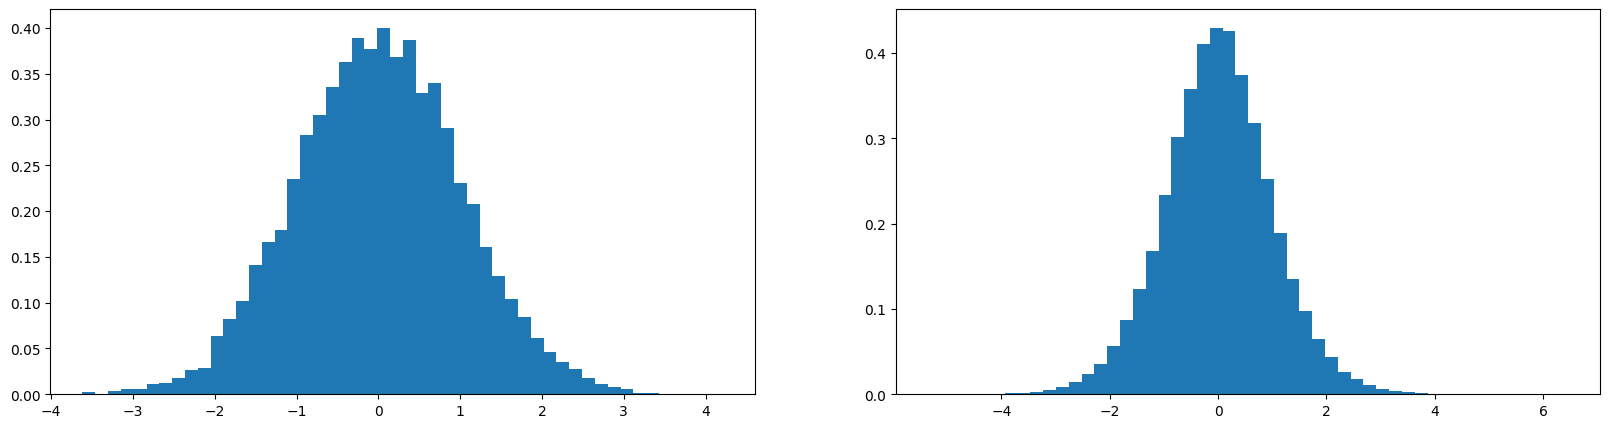

In [ ]:
# More Principled way to set up the initialization of weights

x = torch.randn(1000,10)
w = torch.randn(10, 200) / 10**0.5
# we want most neural networks to have relatively similar activations,
# so unit gaussian roughly throughout the neural net
# This is now less important as we have:
# 1. ResNet
# 2. Batch normalization, Layer, Group normalization
# 3. better optimization such as AmsProp, Adam
# So usually just use sqrt(fan_in)
y = x@w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);


## Batch Normalization

In [ ]:
# We want the hpreact to be roughly gaussian,  not too big, not too small.

In [104]:
# Let's train a deeper network

class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) # /fan_in**0.5 #Kaiming initialization
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    #buffers (trained with a running 'momentum udpate')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True, unbiased=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var

    xhat = (x-xmean)/torch.sqrt(xvar+self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1-self.momentum)*self.running_mean + self.momentum * xmean
        self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
    return self.out
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd*block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(         n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad(): #initialization of the weights
  # last layer: make less confident
  # layers[-1].weight *= 0.1
  layers[-1].gamma *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1 #  0.2 # 5/3 # 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True



# Although without Tanh layers, the NN will collapse to a single linear layer.
# Interestingly though, even though the forward pass collapses to just a linear layer,
#  because of backprop and the dynamics of backward pass, the optimization is actually
# not identical. You actually end up with all kinds of interesting dynamics in the backward
# pass.

47551


In [105]:
len(layers)

17

In [106]:
# same optimization
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update to data ratio

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

  # forward pass
  emb = C[Xb]
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  lossi.append(loss.log10().item())

  with torch.no_grad():
    ud.append([(lr*p.grad.std()/p.data.std()).log10().item() for p in parameters])
  if i>1000:
    break #AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2870


layer 2 (      Tanh): mean +0.00, std 0.63, saturated: 2.94%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.50%
layer 8 (      Tanh): mean -0.00, std 0.63, saturated: 2.91%
layer 11 (      Tanh): mean -0.00, std 0.64, saturated: 2.81%
layer 14 (      Tanh): mean -0.00, std 0.64, saturated: 2.53%


Text(0.5, 1.0, 'activation distribution')

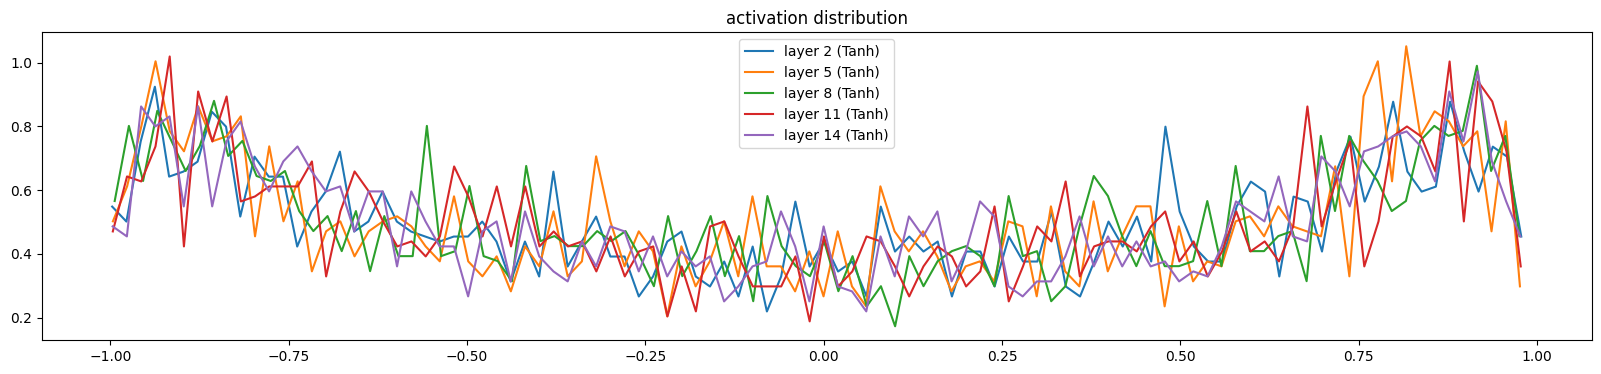

In [107]:
# visualize histogram
plt.figure(figsize=(20,4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends);
plt.title('activation distribution')

# N.B. the std are stabilizing, but if we set the batch normal gain to 1 (instead of 5/3), the std won't be stable, they are shrinking to 0.
# and saturations come to 0. As tanh is a squashing function, if we start with a standard normal gaussion, some gain is necessary to keep
# expanding it to fight against the squashing.

# Without tanh layers, the gain should be 1 instead of 5/3. But if you set the gain too large, you'll see the activations can go anywhere
# and gradients distributions become flat as you go deep into the layers.

layer 2 (      Tanh): mean +0.000000, std 2.506410e-03
layer 5 (      Tanh): mean +0.000000, std 2.169941e-03
layer 8 (      Tanh): mean -0.000000, std 1.887875e-03
layer 11 (      Tanh): mean +0.000000, std 1.637158e-03
layer 14 (      Tanh): mean +0.000000, std 1.488970e-03


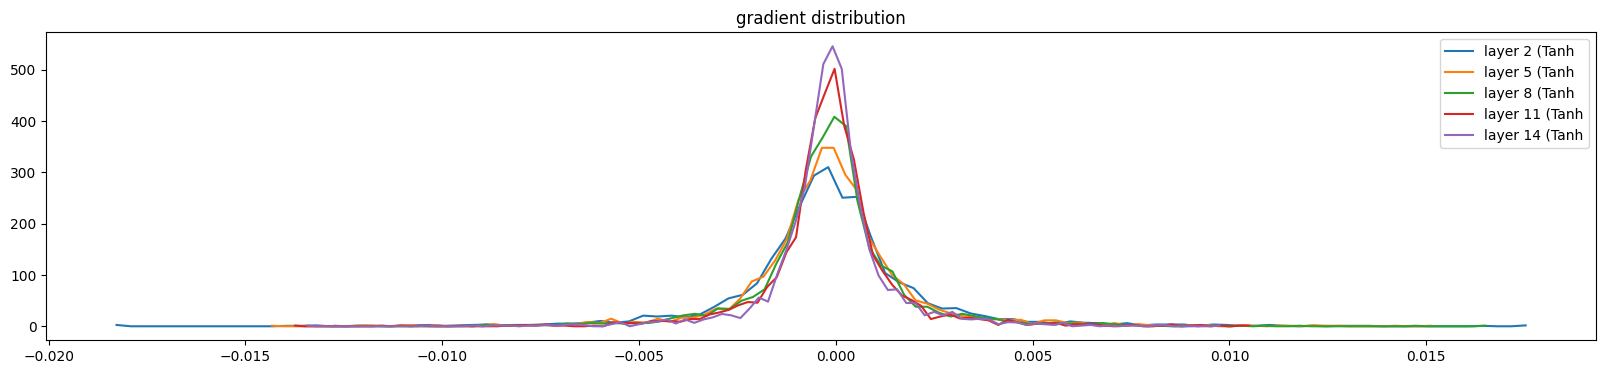

In [108]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e'% (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
  plt.legend(legends)
  plt.title('gradient distribution')

  # all different layers shall have roughly the same gradients, things are not
  # shrinking or exploding. their distributions should overlap
  # Without batch norm, we have to set the initialization carefully to get nice activations in both forward and backward passes

weight   (27, 10) | mean -0.000000 | std 6.678284e-03 | grad:data ratio 6.672537e-03
weight  (30, 100) | mean -0.000017 | std 1.885460e-03 | grad:data ratio 1.839666e-03
weight (100, 100) | mean -0.000024 | std 9.404817e-04 | grad:data ratio 9.435714e-04
weight (100, 100) | mean +0.000004 | std 7.932295e-04 | grad:data ratio 7.874755e-04
weight (100, 100) | mean -0.000001 | std 6.953315e-04 | grad:data ratio 6.931886e-04
weight (100, 100) | mean -0.000002 | std 6.379078e-04 | grad:data ratio 6.353264e-04
weight  (100, 27) | mean -0.000023 | std 1.019904e-03 | grad:data ratio 1.031552e-03


Text(0.5, 1.0, 'weights gradient distribution')

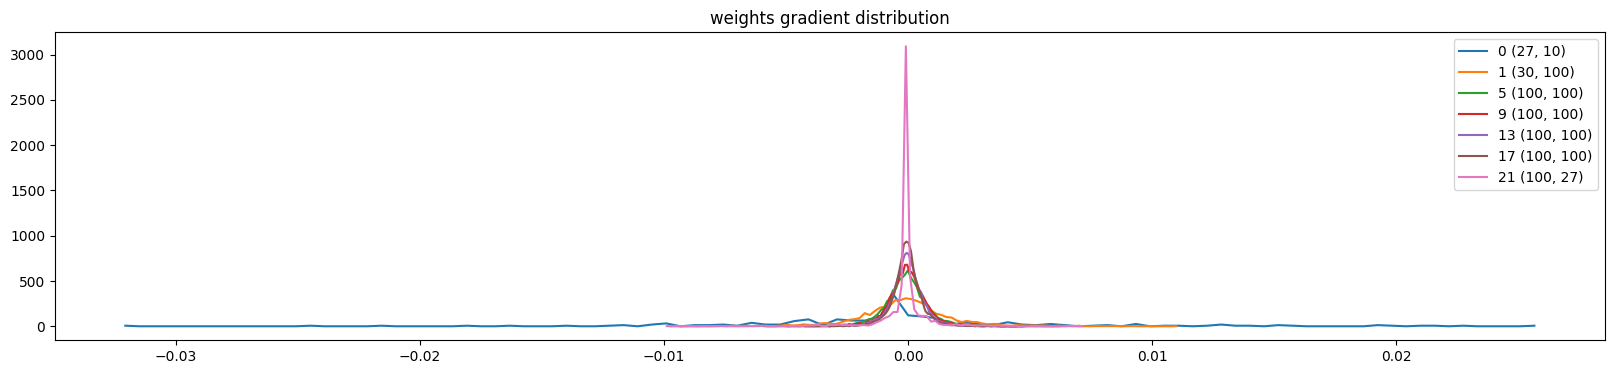

In [109]:
plt.figure(figsize=(20,4))
legends=[]
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # weights of the linear layers
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')

In [86]:
len(ud)

1002

Text(0.5, 1.0, 'updates to data ratio distribution')

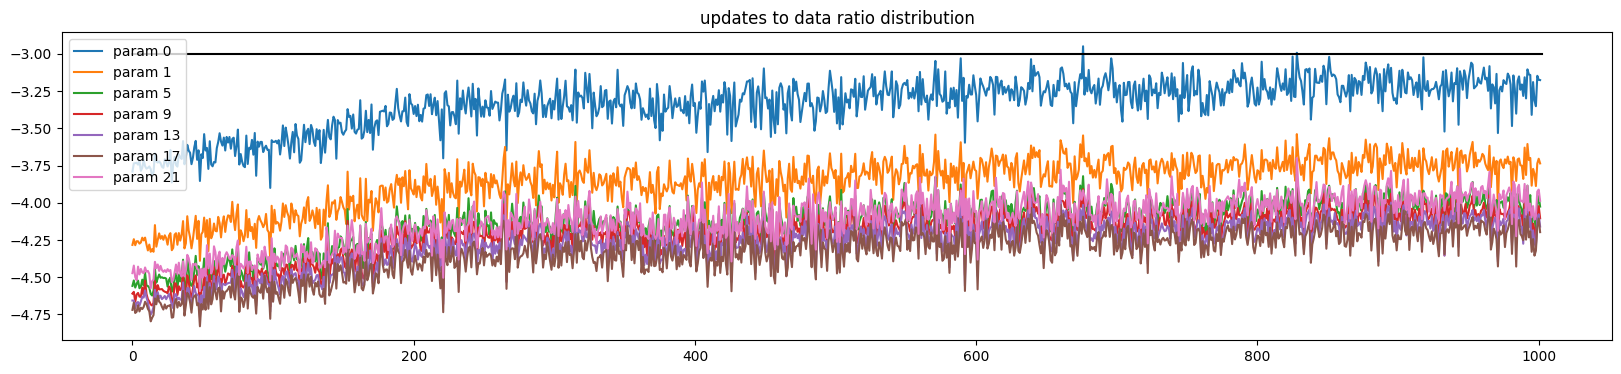

In [110]:
# what actually matters is the update to data ratio
plt.figure(figsize=(20,4))
legends=[]
for i,p in enumerate(parameters):
  if p.ndim == 2: # weights of the linear layers
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append(f'param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~ 1e-3, indicate on plot
plt.legend(legends)
plt.title('updates to data ratio distribution')